In [1]:
import torch
import torch.nn as nn
import torchvision.datasets as datasets
from torchvision import models
from PIL import Image
from torchvision.transforms import v2
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt


In [2]:
import os

In [3]:
!pip install ultralytics

In [4]:
from ultralytics.utils.downloads import download

url = "https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128.zip"
download(url, dir="./", unzip=True)

WARNING ⚠️ Skipping coco128.zip unzip as destination directory /kaggle/working/coco128 is not empty.


In [5]:
contents  =  []
with open("/kaggle/working/coco128/labels/train2017/000000000009.txt", "r") as f:
    contents = f.read().splitlines()
contents

['45 0.479492 0.688771 0.955609 0.5955',
 '45 0.736516 0.247188 0.498875 0.476417',
 '50 0.637063 0.732938 0.494125 0.510583',
 '45 0.339438 0.418896 0.678875 0.7815',
 '49 0.646836 0.132552 0.118047 0.0969375',
 '49 0.773148 0.129802 0.0907344 0.0972292',
 '49 0.668297 0.226906 0.131281 0.146896',
 '49 0.642859 0.0792187 0.148063 0.148062']

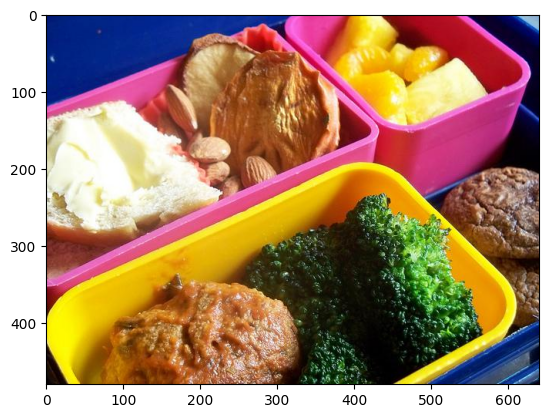

In [6]:
img = Image.open('/kaggle/working/coco128/images/train2017/000000000009.jpg')
plt.imshow(img)

In [7]:
class CustomDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform):
        super().__init__()
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.images_name = os.listdir(images_dir)
        self.images_labels = [name.split('.')[0] + ".txt" for name in self.images_name]
        self.transform = transform

    def __len__(self):
        return len(self.images_name)

    def __getitem__(self, idx):
        img_name, img_labels = self.images_name[idx], self.images_labels[idx]
        img = Image.open(os.path.join(self.images_dir, img_name))
        img = self.transform(img)
        rows = []
        label_path = os.path.join(self.labels_dir, img_labels)
        label_matrix = torch.zeros((7, 7, 80 + 5 * 2))
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                rows = f.read().splitlines()
            for row in rows:
                cls_id, x, y, w, h = map(float, row.strip().split())
                cls_id = int(cls_id)
                i, j = int (7 * y), int (7 * x)
                xc = 7 * x - j
                yc = 7 * y - i
                wc = 7 * w
                hc = 7 * h
                if label_matrix[i, j, 80] == 0:
                    label_matrix[i, j, cls_id] = 1
                    label_matrix[i, j, 80] = 1
                    box_cord = torch.tensor([xc, yc, wc, hc])
                    label_matrix[i, j, 81:85] =  box_cord
        
        return img, label_matrix


In [8]:
transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((448, 448)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
    )
])

In [9]:
images_dir = "/kaggle/working/coco128/images/train2017"
labels_dir = "/kaggle/working/coco128/labels/train2017"
data = CustomDataset(images_dir, labels_dir, transform)

In [10]:
data[100]

(Image([[[ 0.9303,  1.1700,  1.8893,  ...,  0.2624, -0.1143,  0.7248],
         [ 1.5810,  1.9235,  1.9578,  ...,  0.2624,  0.5707,  1.2557],
         [ 1.4269,  2.0605,  1.9407,  ...,  0.6734,  0.8618,  0.8276],
         ...,
         [ 0.3994,  0.6734,  0.4337,  ...,  0.6221,  0.1939,  0.7933],
         [ 0.7248,  1.1358,  0.8276,  ...,  0.6221,  0.1768,  0.1597],
         [ 0.7077,  1.0502,  0.7077,  ...,  0.4166,  0.3823,  0.3309]],
 
        [[ 0.9055,  1.1681,  1.9734,  ...,  0.3452, -0.0574,  0.8179],
         [ 1.6758,  2.0434,  2.1134,  ...,  0.6254,  0.9405,  1.6408],
         [ 1.6583,  2.3235,  2.2535,  ...,  1.2381,  1.4482,  1.4132],
         ...,
         [ 0.3627,  0.6429,  0.3978,  ...,  0.5728,  0.1352,  0.7479],
         [ 0.6954,  1.1155,  0.8004,  ...,  0.6078,  0.1527,  0.1176],
         [ 0.6779,  1.0280,  0.6779,  ...,  0.3978,  0.3627,  0.3102]],
 
        [[ 1.4025,  1.6465,  2.3611,  ..., -0.0441, -0.4798,  0.3742],
         [ 2.0823,  2.3786,  2.4657,  ..., 

In [11]:
train_data, val_data = random_split(data, [0.8, 0.2])
len(train_data), len(val_data)

(103, 25)

In [12]:
train_loader = DataLoader(train_data, 32, shuffle=True)
val_loader = DataLoader(val_data, 32, shuffle=False)

In [13]:
backbone = models.resnet18(weights="DEFAULT")

In [14]:
class YOLOv1(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])
        self.pool = nn.AdaptiveAvgPool2d((7,7))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            nn.Linear(4096, 7 * 7 * (5 * 2 + 80)),
            nn.Sigmoid()
        )
    def forward(self, x):
        out = self.backbone(x)
        out = self.pool(out)
        out = self.head(out)
        return out.reshape(x.size(0), 7, 7, 5 * 2 + 80)
        

In [15]:
model = YOLOv1()

In [16]:
dummy = torch.randn(2, 3,448, 448)
output = model(dummy)
output.shape

torch.Size([2, 7, 7, 90])

In [17]:
DEVICE = "cuda"
model = model.to(DEVICE)

In [18]:
def compute_iou(box1, box2):
    box1_x1 = box1[..., 0:1] - box1[..., 2:3]/2
    box1_y1 = box1[..., 1:2] - box1[..., 3:4]/2
    box1_x2 = box1[..., 0:1] + box1[..., 2:3]/2
    box1_y2 = box1[..., 1:2] + box1[..., 3:4]/2

    box2_x1 = box2[..., 0:1] - box2[..., 2:3]/2
    box2_y1 = box2[..., 1:2] - box2[..., 3:4]/2
    box2_x2 = box2[..., 0:1] + box2[..., 2:3]/2
    box2_y2 = box2[..., 1:2] + box2[..., 3:4]/2

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)

    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    intersection = ((x2 - x1) * (y2 - y1)).clamp(0)
    union = (box1_x2 - box1_x1) * (box1_y2 - box1_y1) + (box2_x2 - box2_x1) * (box2_y2 - box2_y1) - intersection
    return intersection / union
    
    
    
    
    

In [19]:
b1 = torch.tensor([[0.2, 0.3, 0.4, 0.4]])
b2 = torch.tensor([[0.2, 0.3, 0.4, 0.8]])
compute_iou(b1, b2)

tensor([[0.5000]])

# 

In [20]:
class YOLOLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss(reduction="sum")
    def forward(self, predictions, target):
        target_box = target[..., 81:85]
        box1 = predictions[..., 81:85]
        box2 = predictions[..., 86:90]
        iou1 = compute_iou(box1, target_box)
        iou2 = compute_iou(box2, target_box)
        ious = torch.cat((iou1.unsqueeze(0), iou2.unsqueeze(0)), dim=0)
        
        bestbox = ious.argmax(dim=0, keepdim= True)
        exists_box = target[..., 80].unsqueeze(-1)

        
        pred_box = exists_box * ((1 - bestbox) * box1 + bestbox * box2)
        _pred_box = pred_box.clone()
        _target_box = target_box.clone()
        _pred_box[..., 2:4] = torch.sign(_pred_box[..., 2:4]) * torch.sqrt(torch.abs(_pred_box[..., 2:4]) + 1e-6)
        _target_box[..., 2:4] = torch.sqrt(_target_box[...,2:4])
        coord_loss = self.mse(
            torch.flatten(_pred_box, end_dim=-2),
            torch.flatten(_target_box, end_dim=-2),
        )
        pred_conf = exists_box * ((1 - bestbox) * predictions[..., 80:81] + bestbox * predictions[..., 85:86])

        object_loss = self.mse(
            torch.flatten(pred_conf, end_dim= -1),
            torch.flatten(target[..., 80:81], end_dim= -1),
        )

        nobj_loss = self.mse(
            torch.flatten((1-exists_box) * predictions[..., 80:81], end_dim= -1),
            torch.flatten((1 - exists_box) * target[..., 80:81], end_dim= -1)
        ) + self.mse(
            torch.flatten((1-exists_box) * predictions[..., 85:86], end_dim= -1),
            torch.flatten((1 - exists_box) * target[..., 80:81], end_dim= -1)
        )

        class_loss = self.mse(
            torch.flatten( predictions[..., :80], end_dim= -2),
            torch.flatten( target[..., :80], end_dim= -2),
        ) 
        return 5 * coord_loss + object_loss + 0.5 * nobj_loss + class_loss
        


In [21]:
def convert_to_global(box_matrix):
    cell_idx = torch.arange(0, 7).expand(box_matrix.size(0), 7, -1).unsqueeze(-1)
    # out_box = box_matrix.clone()
    box_matrix[..., 81] = (box_matrix[..., 81] + cell_idx) / 7
    box_matrix[..., 82] = (box_matrix[..., 82] + cell_idx.permute(0, 2,1)) / 7
    box_matrix[...,  83] = box_matrix[..., 83] / 7
    box_matrix[...,  84] = box_matrix[..., 84] / 7
    return box_matrix
    

In [22]:
from tqdm import tqdm

In [23]:
criterion = YOLOLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-4,  weight_decay=0.01, betas = (0.9, 0.99))

In [24]:
def train(epoch, epochs, train_loader):
    model.train()
    losses = []
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        out = model(imgs)
        loss = criterion(out, labels)
        losses.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    epoch_loss = sum(losses)/len(losses)

In [25]:
def training(epochs, train_loader):
    for epoch in range(1, epochs + 1):
        train_loss = train(epoch, epochs, train_loader)
        print(f"Train loss: {train_loss}")

In [26]:
training(10, train_loader)

Epoch 1/10:   0%|          | 0/4 [00:00<?, ?it/s]


RuntimeError: one of the variables needed for gradient computation has been modified by an inplace operation: [torch.cuda.FloatTensor [1, 32, 7, 7, 2]], which is output 0 of AsStridedBackward0, is at version 1; expected version 0 instead. Hint: enable anomaly detection to find the operation that failed to compute its gradient, with torch.autograd.set_detect_anomaly(True).